In [1]:
#DATA
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from fred import Fred
import requests
import zipfile
import io
from datetime import timedelta, datetime


#HMM
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from scipy.optimize import minimize
import numpy as np


#SAVING
import joblib

SAVING AND RETRIVEING

In [ ]:
# Save
joblib.dump(clean_master, 'clean_master.pkl')
joblib.dump(model, 'hmm_model.pkl')

['hmm_model.pkl']

In [3]:
#Retrieve
clean_master = joblib.load('clean_master.pkl')
model = joblib.load('hmm_model.pkl')

FRED DATA

In [3]:
api_key = 'de8cb32049ae576e215c319562e439ba'

In [5]:
fr = Fred(api_key=api_key, response_type='df')

In [ ]:
# def get_fred_data(series_ID, observation_start = '2019-01-01', observation_end = '9999-12-31', file_type = 'json'):


#     url = f'https://api.stlouisfed.org/fred/series/observations?series_id={series_ID}&api_key={api_key}&file_type={file_type}&realtime_start={observation_start}&realtime_end={observation_end}'
#     return requests.get(url).json()


# def get_fred_data(series_ID, observation_start='2000-01-01', observation_end='2026-01-31', file_type='json'):
    
#     start = datetime.strptime(observation_start, '%Y-%m-%d')
#     end = datetime.strptime(observation_end, '%Y-%m-%d')
    
#     all_observations = []
#     chunk_start = start
    
#     # request in 5 year chunks to stay under 2000 vintage date limit
#     while chunk_start < end:
#         chunk_end = min(chunk_start + timedelta(days=365*5), end)
        
#         url = f'https://api.stlouisfed.org/fred/series/observations?series_id={series_ID}&api_key={api_key}&file_type={file_type}&observation_start={chunk_start.strftime("%Y-%m-%d")}&observation_end={chunk_end.strftime("%Y-%m-%d")}'
        
#         response = requests.get(url).json()
        
#         if 'observations' in response:
#             all_observations.extend(response['observations'])
        
#         chunk_start = chunk_end + timedelta(days=1)
    
#     return all_observations


# def convert_to_dataframe(json_data):
#     observations = json_data['observations']
#     dates = [obs['date'] for obs in observations]
#     values = [(obs['value']) for obs in observations]

#     series = pd.to_numeric(pd.Series(values, index=pd.to_datetime(dates)), errors='coerce')

#     return series


# def convert_to_series(observations):
#     dates = [obs['date'] for obs in observations]
#     values = [obs['value'] for obs in observations]
#     series = pd.to_numeric(pd.Series(values, index=pd.to_datetime(dates)), errors='coerce')
#     series = series[~series.index.duplicated()]
#     series.sort_index(inplace=True)
#     return series





def get_fred_data(series_ID, observation_start='2000-01-01', observation_end='2026-01-31', file_type='json'):
    url = f'https://api.stlouisfed.org/fred/series/observations?series_id={series_ID}&api_key={api_key}&file_type={file_type}&observation_start={observation_start}&observation_end={observation_end}'
    response = requests.get(url).json()
    return response['observations']


def convert_to_series(observations, name=None):
    dates = [obs['date'] for obs in observations]
    values = [obs['value'] for obs in observations]
    series = pd.to_numeric(pd.Series(values, index=pd.to_datetime(dates), name=name), errors='coerce')
    series.sort_index(inplace=True)
    return series


In [162]:
ten_two_diff = {
                "observation_start": '2000-01-01',
                "observation_end":'2026-01-31',
                "series_ID": 'T10Y2Y',
                "file_type": 'json'
}

bond_to_treasury_yield = {
                "observation_start": '2000-01-01',
                "observation_end":'2026-01-31',
                "series_ID": 'BAA10Y',
                "file_type": 'json'
}

ten_year_two_year = get_fred_data(series_ID=ten_two_diff['series_ID'], observation_start = ten_two_diff['observation_start'], file_type=ten_two_diff['file_type'], observation_end = ten_two_diff['observation_end'])
bond_to_treasury = get_fred_data(series_ID=bond_to_treasury_yield['series_ID'], observation_start = bond_to_treasury_yield['observation_start'], file_type=bond_to_treasury_yield['file_type'], observation_end = bond_to_treasury_yield['observation_end'])

In [168]:
converted_ten_two = convert_to_series(ten_year_two_year, name='Ten-Two Year Treasury Diff')
converted_bond_to_treasury = convert_to_series(bond_to_treasury, name='Bond to Ten Year Treasury')

In [169]:
fred_df = pd.concat([converted_ten_two, converted_bond_to_treasury], axis=1)

FAMA FRENCH FIVE FACTORS AND MOMENTUM

In [ ]:
#FUNCTIONS TO GET DATA

def get_fama_french_data(factor_name):
    url = f'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/{factor_name}_CSV.zip'

    response = requests.get(url)

    zf = zipfile.ZipFile(io.BytesIO(response.content))

    if factor_name == 'F-F_Research_Data_5_Factors_2x3_daily':
        df = pd.read_csv(zf.open(zf.namelist()[0]), skiprows=3, index_col=0)
    elif factor_name == 'F-F_Momentum_Factor_daily':
        df = pd.read_csv(zf.open(zf.namelist()[0]), skiprows=12, index_col=0)


    df = df[df.index.astype(str).str.strip().str.len() == 8]
    df.index = pd.to_datetime(df.index.astype(str).str.strip(), format="%Y%m%d")
    df = df.apply(pd.to_numeric, errors="coerce") / 100
    df.dropna(how="all", inplace=True)

    return df
    

In [142]:
#RETRIEVE DATA
fama_five_factors = get_fama_french_data('F-F_Research_Data_5_Factors_2x3_daily')
fama_momentum = get_fama_french_data('F-F_Momentum_Factor_daily')

In [ ]:
#Specify dates and combine into one fama DF
fama_five_factors = fama_five_factors[(fama_five_factors.index >= '2000-01-01') & (fama_five_factors.index <= '2026-01-31')]
fama_momentum = fama_momentum[(fama_momentum.index >= '2000-01-01') & (fama_momentum.index <= '2026-01-31')]

fama_df = pd.concat([fama_five_factors, fama_momentum], axis=1)

fama_df.head()

SPY DATA

In [ ]:

#Get SPY DATA
spy_data = yf.download("SPY", start="2000-01-01", end="2026-01-31", interval='1d', auto_adjust=True)


#Add the realized volatility and trailing returns 
closing_spy = spy_data['Close']

spy_returns = closing_spy.pct_change()
realized_volatility = spy_returns.rolling(window=21).std() * (252 ** .5)
trailing_return = closing_spy.pct_change(21)


spy_df = pd.DataFrame({
    'Close': closing_spy['SPY'],
    'Realized Volatility(annualized 21 day)': realized_volatility['SPY'],
    'Trailing Return(21 day)': trailing_return['SPY']
})



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


VIX DATA

In [ ]:
#get vix data

vix_data = yf.download("^VIX", start="2000-01-01", end="2026-01-31", auto_adjust=True, interval='1d')

#Find 21 day change
vix_change = vix_data['Close'].pct_change(21)

#make df

vix_df = pd.DataFrame({
    'VIX Forward Looking': vix_data['Close']['^VIX'],
    'VIX change 21 day': vix_change['^VIX']
})


MASTER DF AND CONVERSTION INTO ARRAY

In [ ]:
clean_master = master_df = pd.concat([vix_df, spy_df.drop(columns=['Close']), fred_df], axis=1).dropna()

C:\Users\Kushal Kantharaju\AppData\Local\Temp\ipykernel_33516\1537899506.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  clean_master = master_df = pd.concat([vix_df, spy_df.drop(columns=['Close']), fred_df], axis=1).dropna()


In [ ]:
scaler = StandardScaler()
hmm_scaled = scaler.fit_transform(clean_master)

MODEL

In [215]:
model = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=100
)

model.fit(hmm_scaled)

,n_components,3
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,None


In [ ]:
regimes = model.predict(hmm_scaled)

In [226]:
clean_master['Regime'] = regimes

In [ ]:
# print(clean_master.groupby('Regime')[['VIX Forward Looking', 'Realized Volatility(annualized 21 day)', 'Ten-Two Year Treasury Diff', 'Bond to Ten Year Treasury']].mean())

regime_labels = {0: 'Low Vol', 1: 'Crisis', 2: 'Transitional'}
clean_master['Regime Label'] = clean_master['Regime'].map(regime_labels)


In [247]:
# clean_master = clean_master.join(fama_df, how='left')

fama_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']

print(clean_master.groupby('Regime')[fama_cols].mean())


          Mkt-RF       SMB       HML       RMW       CMA       Mom
Regime                                                            
0       0.000589 -0.000069  0.000111  0.000116 -0.000042  0.000252
1      -0.000465 -0.000216 -0.000670  0.000241 -0.000186 -0.000830
2       0.000297  0.000269  0.000355  0.000264  0.000301  0.000311


In [ ]:

fama_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']

regime_stats = {}

for regime in [0,1,2]:
    subset = clean_master[clean_master['Regime'] == regime][fama_cols]

    regime_stats[regime] = {
        'mean': subset.mean().values,
        'cov': subset.cov().values
    }


In [ ]:
print(regime_stats)

In [ ]:
def max_sharpe_weights(mean_returns, cov_matrix):
    n = len(mean_returns)

    def neg_sharpe(w):
        portfolio_return = w @ mean_returns
        portfolio_vol = np.sqrt(w @ cov_matrix @ w)
        return -portfolio_return / portfolio_vol
    
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    bounds = [(0,1)] * n
    w0 = np.ones(n) / n

    result = minimize(neg_sharpe, w0, bounds=bounds, constraints=constraints)
    return result.x

regime_weights = {}

for regime, stats in regime_stats.items():

    weights = max_sharpe_weights(stats['mean'], stats['cov'])
    regime_weights[regime] = weights

    print(f'\nRegime {regime}:')

    for factor, w, in zip(fama_cols, weights):
        print(f'{factor}: {w:4f}')



In [ ]:
factor_returns = clean_master[fama_cols].values

weight_matrix = np.array([regime_weights[r] for r in clean_master['Regime']])

clean_master['Strategy Return'] = (weight_matrix * factor_returns).sum(axis=1)
clean_master['Benchmark Return'] = factor_returns.mean(axis=1)


            Regime  Strategy Return  Benchmark Return
2000-02-02       1        -0.010300          0.001783
2000-02-03       1        -0.009600          0.000367
2000-02-04       1        -0.003200          0.001600
2000-02-07       1        -0.010800          0.000400
2000-02-08       2        -0.002521         -0.002133
2000-02-09       2         0.001042          0.000117
2000-02-10       2         0.000033          0.001833
2000-02-11       2        -0.000697         -0.000283
2000-02-14       2         0.002215          0.002333
2000-02-15       2         0.001272          0.000950


In [ ]:
print(clean_master[['Regime', 'Strategy Return', 'Benchmark Return']].head(50))


In [ ]:
clean_master['Strategy Cumulative'] = (1 + clean_master['Strategy Return']).cumprod()
clean_master['Benchmark Cumulative'] = (1 + clean_master['Benchmark Return']).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(clean_master.index, clean_master['Strategy Cumulative'], label='HMM Strategy', linewidth=1.5)
plt.plot(clean_master.index, clean_master['Benchmark Cumulative'], label='Equal Weight Benchmark', linewidth=1.5)
plt.title('HMM Factor Allocation Strategy vs Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
trading_days = 252

strategy_sharpe = (clean_master['Strategy Return'].mean() / clean_master['Strategy Return'].std()) * np.sqrt(trading_days)
benchmark_sharpe = (clean_master['Benchmark Return'].mean() / clean_master['Benchmark Return'].std()) * np.sqrt(trading_days)

def max_drawdown(cumulative):
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    return drawdown.min()

print(f"Strategy Sharpe: {strategy_sharpe:.3f}")
print(f"Benchmark Sharpe: {benchmark_sharpe:.3f}")
print(f"Strategy Max Drawdown: {max_drawdown(clean_master['Strategy Cumulative']):.3f}")
print(f"Benchmark Max Drawdown: {max_drawdown(clean_master['Benchmark Cumulative']):.3f}")
print(f"Strategy Annualized Return: {clean_master['Strategy Return'].mean() * trading_days:.3f}")
print(f"Benchmark Annualized Return: {clean_master['Benchmark Return'].mean() * trading_days:.3f}")

Strategy Sharpe: 1.215
Benchmark Sharpe: 0.805
Strategy Max Drawdown: -0.117
Benchmark Max Drawdown: -0.136
Strategy Annualized Return: 0.074
Benchmark Annualized Return: 0.038


In [22]:
clean_master.head()

,VIX Forward Looking,VIX change 21 day,Realized Volatility(annualized 21 day),Trailing Return(21 day),Ten-Two Year Treasury Diff,Bond to Ten Year Treasury,Regime,Regime Label,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom,Strategy Return,Benchmark Return,Strategy Cumulative,Benchmark Cumulative
2000-02-02,23.120001,-0.045023,0.335596,-0.030082,-0.03,1.62,1,Crisis,0.0015,0.0124,-0.0030,-0.0103,0.0022,0.0002,0.0079,-0.010300,0.001783,0.989700,1.001783
2000-02-03,22.010000,-0.185117,0.310082,0.024597,-0.07,1.64,1,Crisis,0.0149,0.0099,-0.0145,-0.0096,-0.0080,0.0002,0.0095,-0.009600,0.000367,0.980199,1.002151
2000-02-04,21.540001,-0.184400,0.310654,0.018527,-0.10,1.60,1,Crisis,-0.0004,0.0119,-0.0071,-0.0032,-0.0020,0.0002,0.0104,-0.003200,0.001600,0.977062,1.003754
2000-02-07,22.790001,-0.114263,0.304579,0.033575,-0.04,1.66,1,Crisis,0.0036,0.0130,-0.0133,-0.0108,0.0009,0.0002,0.0090,-0.010800,0.000400,0.966510,1.004156
2000-02-08,21.250000,-0.021639,0.231032,-0.009862,-0.10,1.59,2,Transitional,0.0123,0.0010,-0.0172,-0.0161,-0.0089,0.0002,0.0161,-0.002521,-0.002133,0.964073,1.002013


In [ ]:
data = clean_master.drop(columns=['Regime', 'Strategy Return', 'Benchmark Return', 'Strategy Cumulative', 'Benchmark Cumulative', 'Regime Label'])

data

In [28]:
hmm_features = ['VIX Forward Looking', 'VIX change 21 day', 
                 'Realized Volatility(annualized 21 day)', 
                 'Trailing Return(21 day)', 
                 'Ten-Two Year Treasury Diff', 
                 'Bond to Ten Year Treasury']

train = data[data.index < '2020-01-01']
test = data[data.index >= '2020-01-01']

print(f"Train: {train.index[0].date()} to {train.index[-1].date()} ({len(train)} days)")
print(f"Test: {test.index[0].date()} to {test.index[-1].date()} ({len(test)} days)")

Train: 2000-02-02 to 2019-12-31 (4971 days)
Test: 2020-01-02 to 2026-01-30 (1516 days)


In [29]:
# Scale train features
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train[hmm_features])

# Fit HMM on train only
train_model = GaussianHMM(n_components=3, covariance_type='full', n_iter=1000, random_state=42)
train_model.fit(train_scaled)

# Scale test features using the SAME scaler fitted on train
test_scaled = scaler.transform(test[hmm_features])

# Predict regimes on test
test_regimes = train_model.predict(test_scaled)
print(pd.Series(test_regimes).value_counts())

2    923
1    297
0    296
Name: count, dtype: int64


In [30]:
test_df = test.copy()
test_df['Regime'] = test_regimes

print(test_df.groupby('Regime')[hmm_features].mean())

        VIX Forward Looking  VIX change 21 day  \
Regime                                           
0                 15.430811          -0.036423   
1                 15.478754          -0.030062   
2                 24.469827           0.098265   

        Realized Volatility(annualized 21 day)  Trailing Return(21 day)  \
Regime                                                                    
0                                     0.107176                 0.026114   
1                                     0.106661                 0.025758   
2                                     0.213488                 0.005244   

        Ten-Two Year Treasury Diff  Bond to Ten Year Treasury  
Regime                                                         
0                         0.209155                   1.743007  
1                         0.205556                   1.744545  
2                         0.243359                   2.145114  


In [32]:
for seed in [0, 7, 13, 21, 99]:
    m = GaussianHMM(n_components=3, covariance_type='full', n_iter=1000, random_state=seed)
    m.fit(train_scaled)
    regimes = m.predict(train_scaled)
    means = train[hmm_features[0]].groupby(pd.Series(regimes, index=train.index)).mean()
    print(f"Seed {seed}: {means.to_dict()}")

Seed 0: {0: 13.101786771936741, 1: 27.84918146906672, 2: 19.358612912024746}
Seed 7: {0: 17.774883987547717, 1: 16.070814550852653, 2: 35.072339447266465}
Seed 13: {0: 13.096809115504946, 1: 18.50362360187173, 2: 29.28281467861229}
Seed 21: {0: 15.769069231598385, 1: 34.61332846732035, 2: 17.91858557513701}
Seed 99: {0: 13.101786771936741, 1: 27.84918146906672, 2: 19.358612912024746}


In [31]:
test_regimes

array([2, 1, 0, ..., 0, 1, 0], shape=(1516,))

In [33]:
train_model = GaussianHMM(n_components=3, covariance_type='full', n_iter=1000, random_state=21)
train_model.fit(train_scaled)

test_scaled = scaler.transform(test[hmm_features])
test_regimes = train_model.predict(test_scaled)

test_df = test.copy()
test_df['Regime'] = test_regimes
print(test_df.groupby('Regime')[['VIX Forward Looking', 'Realized Volatility(annualized 21 day)']].mean())

        VIX Forward Looking  Realized Volatility(annualized 21 day)
Regime                                                             
0                 19.069023                                0.152316
1                 28.365455                                0.248815
2                 17.107273                                0.135854


In [34]:
label_map = {
    0: 2,  # new regime 0 (Transitional) → original regime 2 weights
    1: 1,  # new regime 1 (Crisis) → original regime 1 weights
    2: 0   # new regime 2 (Low Vol) → original regime 0 weights
}

test_df['Regime Mapped'] = test_df['Regime'].map(label_map)

In [35]:
# Build weight matrix using mapped regimes
test_weight_matrix = np.array([
    regime_weights[r] for r in test_df['Regime Mapped']
])

# Daily strategy return on test period
test_factor_returns = test_df[fama_cols].values
test_df['Strategy Return'] = (test_weight_matrix * test_factor_returns).sum(axis=1)
test_df['Benchmark Return'] = test_factor_returns.mean(axis=1)

# Cumulative returns
test_df['Strategy Cumulative'] = (1 + test_df['Strategy Return']).cumprod()
test_df['Benchmark Cumulative'] = (1 + test_df['Benchmark Return']).cumprod()

# Performance metrics
trading_days = 252
test_sharpe = (test_df['Strategy Return'].mean() / test_df['Strategy Return'].std()) * np.sqrt(trading_days)
bench_sharpe = (test_df['Benchmark Return'].mean() / test_df['Benchmark Return'].std()) * np.sqrt(trading_days)

print(f"Test Strategy Sharpe: {test_sharpe:.3f}")
print(f"Test Benchmark Sharpe: {bench_sharpe:.3f}")
print(f"Test Strategy Max Drawdown: {max_drawdown(test_df['Strategy Cumulative']):.3f}")
print(f"Test Benchmark Max Drawdown: {max_drawdown(test_df['Benchmark Cumulative']):.3f}")
print(f"Test Strategy Annualized Return: {test_df['Strategy Return'].mean() * trading_days:.3f}")
print(f"Test Benchmark Annualized Return: {test_df['Benchmark Return'].mean() * trading_days:.3f}")

Test Strategy Sharpe: 0.846
Test Benchmark Sharpe: 0.520
Test Strategy Max Drawdown: -0.082
Test Benchmark Max Drawdown: -0.109
Test Strategy Annualized Return: 0.055
Test Benchmark Annualized Return: 0.032


In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(test_df.index, test_df['Strategy Cumulative'], label='HMM Strategy', linewidth=1.5)
plt.plot(test_df.index, test_df['Benchmark Cumulative'], label='Equal Weight Benchmark', linewidth=1.5)
plt.title('Out-of-Sample Test: HMM Strategy vs Benchmark (2020-2026)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
# Save api dataframe

data.to_pickle('data.pkl')

# Save HMM models
joblib.dump(model, 'full_model.pkl')           # original full-sample model
joblib.dump(train_model, 'train_model.pkl')    # train-only model

# Save scaler
joblib.dump(scaler, 'scaler.pkl')

# Save dataframes
clean_master.to_pickle('clean_master.pkl')
train.to_pickle('train.pkl')
test.to_pickle('test.pkl')
test_df.to_pickle('test_df.pkl')

# Save weights and stats
joblib.dump(regime_weights, 'regime_weights.pkl')
joblib.dump(regime_stats, 'regime_stats.pkl')

print("All objects saved successfully")

All objects saved successfully


In [3]:
#Loading 

model = joblib.load('full_model.pkl')
train_model = joblib.load('train_model.pkl')
scaler = joblib.load('scaler.pkl')
regime_weights = joblib.load('regime_weights.pkl')
regime_stats = joblib.load('regime_stats.pkl')

clean_master = pd.read_pickle('clean_master.pkl')
train = pd.read_pickle('train.pkl')
test = pd.read_pickle('test.pkl')
test_df = pd.read_pickle('test_df.pkl')


fama_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']
hmm_features = ['VIX Forward Looking', 'VIX change 21 day',
                 'Realized Volatility(annualized 21 day)',
                 'Trailing Return(21 day)',
                 'Ten-Two Year Treasury Diff',
                 'Bond to Ten Year Treasury']

print("All objects loaded successfully")

All objects loaded successfully


Full regime series: 2000-02-03 → 2026-01-30
Regime distribution:
regime
0.0    1773
1.0     993
2.0    3720
Name: count, dtype: int64

Trading days in backtest: 3127

ETF allocation per regime:
  Regime 0: {'SPY': '41.3%', 'IWM': '0.0%', 'IVE': '12.1%', 'QUAL': '40.5%', 'USMV': '0.0%', 'MTUM': '6.0%'}
  Regime 1: {'SPY': '0.0%', 'IWM': '0.0%', 'IVE': '0.0%', 'QUAL': '100.0%', 'USMV': '0.0%', 'MTUM': '0.0%'}
  Regime 2: {'SPY': '16.8%', 'IWM': '21.1%', 'IVE': '5.1%', 'QUAL': '23.6%', 'USMV': '21.9%', 'MTUM': '11.4%'}


── Full Period ──
                                   Ann.Ret     Vol   Sharpe      MaxDD      Final $
  HMM Portfolio                     13.42%  16.83%     0.80    -33.64%      $44,322
  S&P 500 (SPY)                     14.58%  17.14%     0.85    -33.72%      $50,829

── Train Period ──
                                   Ann.Ret     Vol   Sharpe      MaxDD      Final $
  HMM Portfolio                     12.64%  12.82%     0.99    -19.77%      $21,279
  S&P 500 (SPY)   

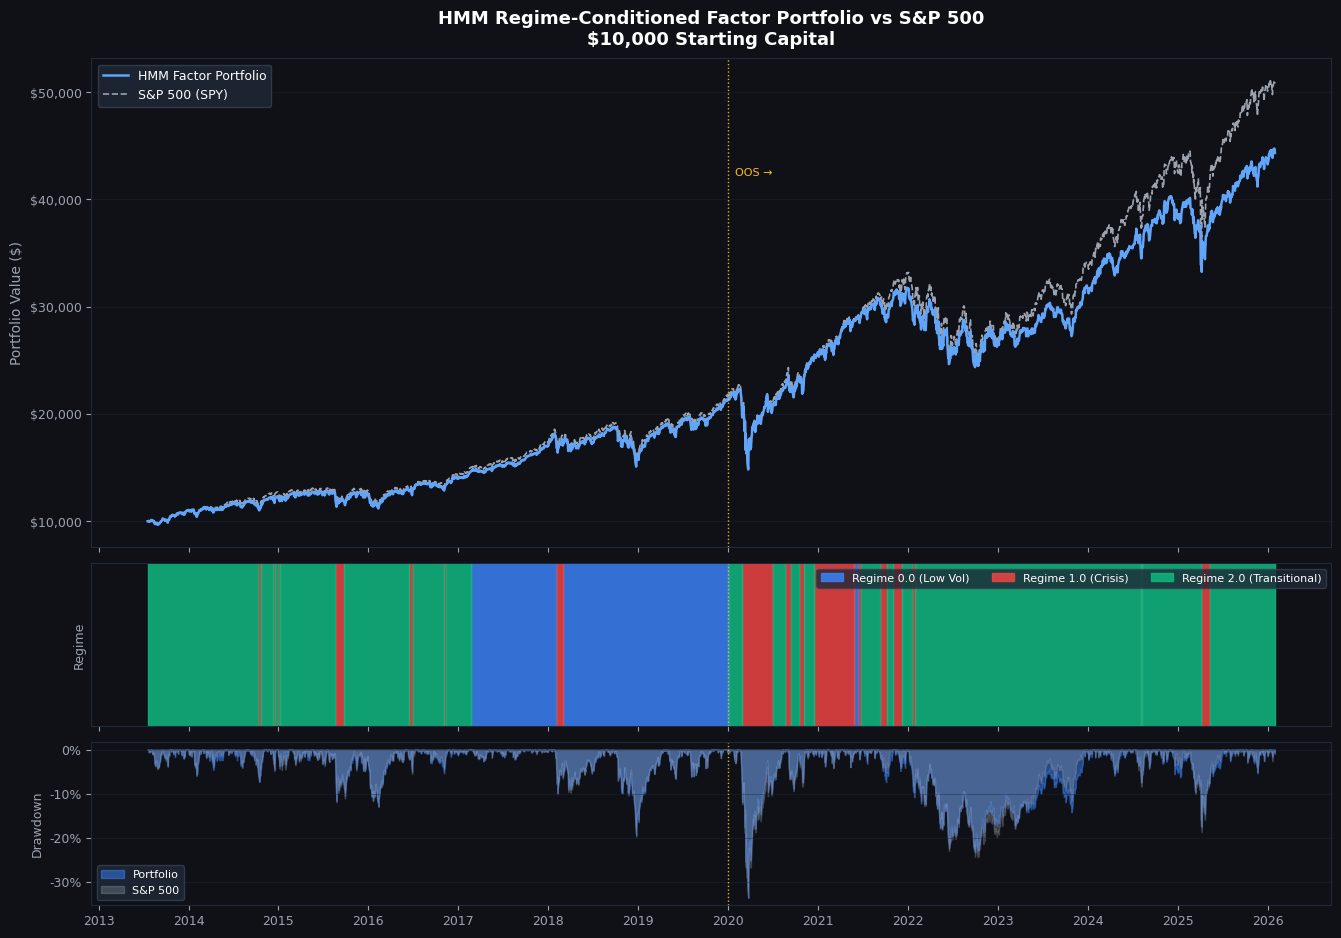

In [4]:
"""
HMM Paper Portfolio Backtest

What this does:
- Builds a dollar NAV portfolio using ETF proxies for each FF factor
- Regime signal is lagged 1 day (no lookahead bias)
- Train period: uses train_model predictions on train data
- Test period:  uses train_model predictions on test data + label_map
- Benchmarks against SPY total return
- Starting capital: $10,000
"""

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

# ── Config ───────────────────────────────────────────────────────────────────
STARTING_CAPITAL = 10_000
TRAIN_CUTOFF     = '2020-01-01'

# FF factor → investable ETF proxy
FACTOR_ETF = {
    'Mkt-RF': 'SPY',   # broad market
    'SMB':    'IWM',   # small cap (Russell 2000)
    'HML':    'IVE',   # value (S&P 500 Value)
    'RMW':    'QUAL',  # quality / high profitability
    'CMA':    'USMV',  # low vol / conservative (best CMA proxy)
    'Mom':    'MTUM',  # momentum
}

BENCHMARK = 'SPY'

# ── Step 1: Build regime series for full period ───────────────────────────────
# Train: predict using train_model on train features
train_scaled_bt = scaler.transform(train[hmm_features])
train_regimes_bt = pd.Series(
    train_model.predict(train_scaled_bt),
    index=train.index,
    name='regime'
)

# Test: predict and apply label_map (same as your Cell 43)
test_scaled_bt  = scaler.transform(test[hmm_features])
test_regimes_raw = pd.Series(
    train_model.predict(test_scaled_bt),
    index=test.index
)
label_map = {0: 2, 1: 1, 2: 0}
test_regimes_bt = test_regimes_raw.map(label_map).rename('regime')

# Combine and lag by 1 day — today's weights = yesterday's regime
full_regimes = pd.concat([train_regimes_bt, test_regimes_bt]).sort_index()
full_regimes_lagged = full_regimes.shift(1).dropna()

print(f"Full regime series: {full_regimes_lagged.index[0].date()} → {full_regimes_lagged.index[-1].date()}")
print(f"Regime distribution:\n{full_regimes_lagged.value_counts().sort_index()}")

# ── Step 2: Download ETF prices ───────────────────────────────────────────────
all_etfs   = list(set(FACTOR_ETF.values()) | {BENCHMARK})
start_date = full_regimes_lagged.index.min()
end_date   = full_regimes_lagged.index.max()

print(f"\nDownloading ETFs: {all_etfs}")
prices = yf.download(
    all_etfs,
    start=start_date,
    end=end_date + pd.Timedelta(days=1),
    auto_adjust=True,
    progress=False
)['Close']
prices.dropna(inplace=True)

# Align regime series to trading days we have ETF data for
common_dates  = full_regimes_lagged.index.intersection(prices.index)
etf_returns   = prices.loc[common_dates].pct_change().dropna()
regime_series = full_regimes_lagged.loc[etf_returns.index]

print(f"Trading days in backtest: {len(etf_returns)}")

# ── Step 3: Precompute ETF weight dict per regime ─────────────────────────────
def factor_arr_to_etf_weights(weight_arr, fama_cols, factor_etf):
    """
    Converts numpy weight array aligned to fama_cols
    into a normalized dict of {etf: weight}.
    Handles the case where multiple factors map to the same ETF (e.g. SPY).
    """
    etf_w = {}
    for factor, w in zip(fama_cols, weight_arr):
        etf = factor_etf.get(factor)
        if etf:
            etf_w[etf] = etf_w.get(etf, 0) + w
    total = sum(etf_w.values())
    return {k: v / total for k, v in etf_w.items()}

regime_etf_weights = {
    r: factor_arr_to_etf_weights(regime_weights[r], fama_cols, FACTOR_ETF)
    for r in regime_weights
}

print("\nETF allocation per regime:")
for r, w in regime_etf_weights.items():
    print(f"  Regime {r}: { {k: f'{v:.1%}' for k, v in w.items()} }")

# ── Step 4: Simulate dollar portfolio day by day ──────────────────────────────
portfolio_nav = STARTING_CAPITAL
benchmark_nav = STARTING_CAPITAL
records = []

for date, ret_row in etf_returns.iterrows():
    regime        = regime_series.loc[date]
    target_w      = regime_etf_weights[regime]

    # Weighted ETF return for today using yesterday's regime
    port_return  = sum(target_w.get(etf, 0) * ret_row.get(etf, 0)
                       for etf in FACTOR_ETF.values())
    bench_return = ret_row.get(BENCHMARK, 0)

    # Compound NAV — gains/losses carry forward automatically
    portfolio_nav *= (1 + port_return)
    benchmark_nav *= (1 + bench_return)

    records.append({
        'date':         date,
        'portfolio':    portfolio_nav,
        'benchmark':    benchmark_nav,
        'regime':       regime,
        'port_return':  port_return,
        'bench_return': bench_return,
        'period':       'train' if date < pd.Timestamp(TRAIN_CUTOFF) else 'test'
    })

results = pd.DataFrame(records).set_index('date')

# ── Step 5: Performance metrics ───────────────────────────────────────────────
def performance_metrics(returns, label, starting_capital=STARTING_CAPITAL):
    ann_ret  = returns.mean() * 252
    ann_vol  = returns.std()  * np.sqrt(252)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum      = (1 + returns).cumprod()
    max_dd   = ((cum - cum.cummax()) / cum.cummax()).min()
    final    = starting_capital * cum.iloc[-1]
    return {
        'Strategy':        label,
        'Ann. Return':     f"{ann_ret:.2%}",
        'Ann. Vol':        f"{ann_vol:.2%}",
        'Sharpe':          f"{sharpe:.2f}",
        'Max Drawdown':    f"{max_dd:.2%}",
        'Final Value':     f"${final:,.0f}",
    }

print("\n" + "="*72)
for period_label, mask in [
    ('Full Period',  results['period'].isin(['train', 'test'])),
    ('Train Period', results['period'] == 'train'),
    ('Test Period',  results['period'] == 'test'),
]:
    sub = results[mask]
    m1  = performance_metrics(sub['port_return'],  f'HMM Portfolio')
    m2  = performance_metrics(sub['bench_return'], f'S&P 500 (SPY)')
    print(f"\n── {period_label} ──")
    print(f"  {'':30} {'Ann.Ret':>9} {'Vol':>7} {'Sharpe':>8} {'MaxDD':>10} {'Final $':>12}")
    for m in [m1, m2]:
        print(f"  {m['Strategy']:30} {m['Ann. Return']:>9} {m['Ann. Vol']:>7} "
              f"{m['Sharpe']:>8} {m['Max Drawdown']:>10} {m['Final Value']:>12}")
print("="*72)

# ── Step 6: Plot ──────────────────────────────────────────────────────────────
REGIME_COLORS = {0: '#3B82F6', 1: '#EF4444', 2: '#10B981'}
train_end     = pd.Timestamp(TRAIN_CUTOFF)

fig = plt.figure(figsize=(16, 11), facecolor='#0F1117')
gs  = GridSpec(3, 1, figure=fig, height_ratios=[3, 1, 1], hspace=0.06)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor('#0F1117')
    ax.tick_params(colors='#9CA3AF', labelsize=9)
    ax.spines[:].set_color('#1F2937')
    ax.grid(axis='y', color='#1F2937', linewidth=0.5, alpha=0.6)

# Panel 1 — NAV
ax1.plot(results.index, results['portfolio'], color='#60A5FA',
         linewidth=1.8, label='HMM Factor Portfolio', zorder=3)
ax1.plot(results.index, results['benchmark'], color='#9CA3AF',
         linewidth=1.2, linestyle='--', label='S&P 500 (SPY)', zorder=2)
ax1.axvline(train_end, color='#FBBF24', linewidth=1, linestyle=':', alpha=0.9, zorder=4)
ax1.text(train_end, results['portfolio'].max() * 0.96,
         '  OOS →', color='#FBBF24', fontsize=8, va='top')
ax1.set_ylabel('Portfolio Value ($)', color='#9CA3AF', fontsize=10)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(facecolor='#1F2937', edgecolor='#374151', labelcolor='white', fontsize=9)
ax1.set_title('HMM Regime-Conditioned Factor Portfolio vs S&P 500\n$10,000 Starting Capital',
              color='white', fontsize=13, pad=10, fontweight='bold')

# Panel 2 — Regime bands
for regime in sorted(results['regime'].unique()):
    mask = results['regime'] == regime
    regime_name = {0: 'Low Vol', 1: 'Crisis', 2: 'Transitional'}.get(regime, str(regime))
    ax2.fill_between(results.index, 0, 1, where=mask,
                     color=REGIME_COLORS.get(regime, '#6B7280'),
                     alpha=0.85, label=f'Regime {regime} ({regime_name})')
ax2.axvline(train_end, color='#FBBF24', linewidth=1, linestyle=':', alpha=0.9)
ax2.set_ylim(0, 1)
ax2.set_yticks([])
ax2.set_ylabel('Regime', color='#9CA3AF', fontsize=9)
ax2.legend(facecolor='#1F2937', edgecolor='#374151', labelcolor='white',
           fontsize=8, loc='upper right', ncol=3)

# Panel 3 — Drawdown
port_cum  = (1 + results['port_return']).cumprod()
bench_cum = (1 + results['bench_return']).cumprod()
port_dd   = (port_cum  - port_cum.cummax())  / port_cum.cummax()
bench_dd  = (bench_cum - bench_cum.cummax()) / bench_cum.cummax()

ax3.fill_between(results.index, port_dd,  0, color='#3B82F6', alpha=0.5, label='Portfolio')
ax3.fill_between(results.index, bench_dd, 0, color='#9CA3AF', alpha=0.3, label='S&P 500')
ax3.axvline(train_end, color='#FBBF24', linewidth=1, linestyle=':', alpha=0.9)
ax3.set_ylabel('Drawdown', color='#9CA3AF', fontsize=9)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax3.legend(facecolor='#1F2937', edgecolor='#374151', labelcolor='white', fontsize=8)

ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax3.xaxis.get_majorticklabels(), color='#9CA3AF')
plt.setp(ax1.xaxis.get_majorticklabels(), visible=False)
plt.setp(ax2.xaxis.get_majorticklabels(), visible=False)

plt.savefig('hmm_paper_portfolio.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117', edgecolor='none')
print("\nSaved: hmm_paper_portfolio.png")
plt.show()